### Аналіз Diabetes Dataset для задачі регресії

Diabetes Dataset з `scikit-learn` містить медичні ознаки пацієнтів і числову цільову змінну: прогресування хвороби через рік після базового вимірювання. Це зручний датасет для першої регресійної моделі, бо цільова змінна є числом, а не класом.

#### Dataset

Використовуємо вбудований датасет:

```python
from sklearn.datasets import load_diabetes
```

Дані не потрібно завантажувати з файлу: вони вже входять до `scikit-learn`.

#### Опис колонок

| Колонка | Що означає | Тип даних | Чи корисна для ML |
|---|---|---|---|
| `age` | вік пацієнта | число | так |
| `sex` | закодована стать | число | так |
| `bmi` | індекс маси тіла | число | так, часто добре пояснює target |
| `bp` | середній артеріальний тиск | число | так |
| `s1`-`s6` | показники аналізів крові | число | так |
| `target` | прогресування хвороби через рік | число | це цільова змінна |

Усі ознаки в `load_diabetes()` вже числові та масштабовані.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [30]:
diabetes_df = load_diabetes(as_frame=True).frame

diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [77]:
X = diabetes_df[['bmi']]
y = diabetes_df['target']

In [12]:
diabetes_df.corr()['target'].drop('target').sort_values()

s3    -0.394789
sex    0.043062
s2     0.174054
age    0.187889
s1     0.212022
s6     0.382483
s4     0.430453
bp     0.441482
s5     0.565883
bmi    0.586450
Name: target, dtype: float64

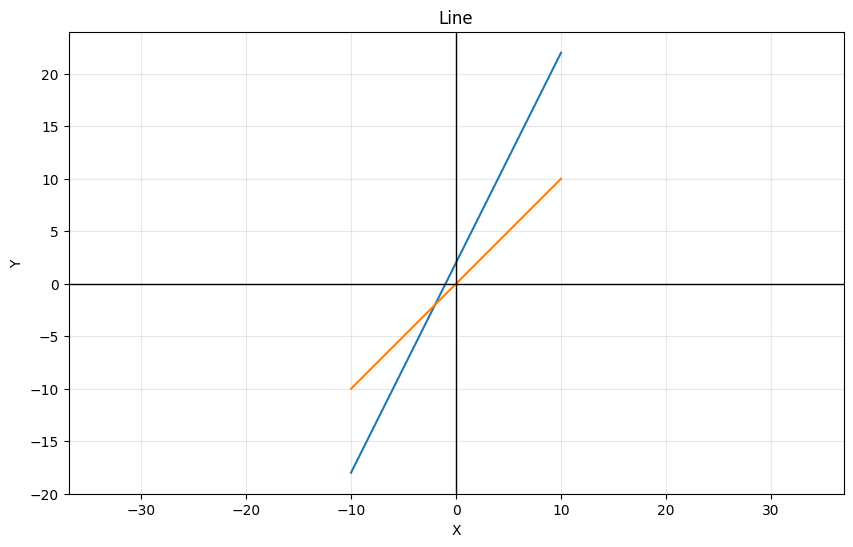

In [27]:
x1 = np.arange(-10, 11)
w1 = 2
b1 = 2
y1 = w1 * x1 + b1

w2 = 1
b2 = 0
y2 = w2 * x1 + b2

plt.figure(figsize=(10, 6))

plt.plot(x1, y1)
plt.plot(x1, y2)
plt.title('Line')
plt.xlabel('X')
plt.ylabel('Y')

plt.axis('equal')

plt.axhline(0, linewidth=1, color='black')
plt.axvline(0, linewidth=1, color='black')
plt.grid(True, alpha=0.3)

plt.show()


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
print(X.shape, y.shape)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(442, 1) (442,)
(353, 1) (89, 1)
(353,) (89,)


In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


w = coef_[0]
b = intercept_

In [40]:
print(model.coef_[0], model.intercept_)

998.5776891375593 152.00335421448167


# Прогноз

In [46]:
y_pred = model.predict(X_test)
# y_test

# Графік лінійної регресії 

коефіцієнти: w=998.5776, b=152

вивести дані: (X_train, y_train), (X_test, y_test)

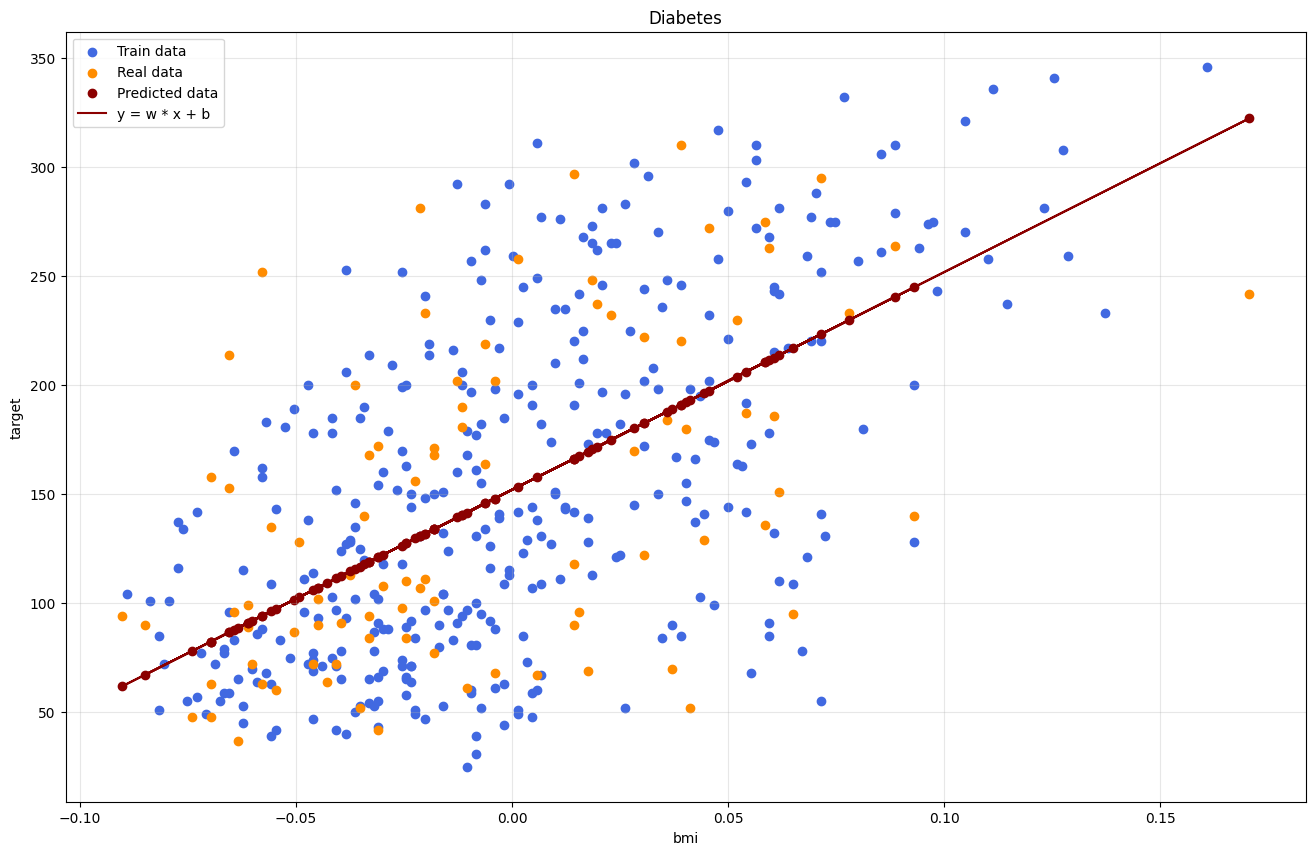

In [51]:
w = model.coef_[0]
b = model.intercept_

plt.figure(figsize=(16, 10))

x = X_test['bmi']
y = w * x + b

# Train data
plt.scatter(X_train['bmi'], y_train, color='royalblue', label='Train data')
# Test data
plt.scatter(X_test['bmi'], y_test, color='darkorange', label='Real data')
# Predict data
plt.scatter(X_test['bmi'], y_pred, color='darkred', label='Predicted data')
# Model Line
plt.plot(x, y, color='darkred', label='y = w * x + b')


plt.title('Diabetes')
plt.xlabel('bmi')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [58]:
diabetes_df.describe()['target']

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [53]:
errors_df = pd.DataFrame({
    'y_pred': y_pred,
    'y_real': y_test,
    'error': y_pred - y_test,
    'error_abs': np.abs(y_pred - y_test)
})
errors_df

,y_pred,y_real,error,error_abs
287,145.806227,219.0,-73.193773,73.193773
211,188.857390,70.0,118.857390,118.857390
72,147.958785,202.0,-54.041215,54.041215
321,203.925298,230.0,-26.074702,26.074702
73,131.814599,111.0,20.814599,20.814599
...,...,...,...,...
255,86.610877,153.0,-66.389123,66.389123
90,126.433203,98.0,28.433203,28.433203
57,88.763435,37.0,51.763435,51.763435
391,82.305761,63.0,19.305761,19.305761


MAE - Mean Absolute Error

In [55]:
errors_df['error_abs'].mean()

np.float64(52.25997644534553)

In [60]:
mae = mean_absolute_error(y_test, y_pred)
mae

52.25997644534553

MSE - Mean Squared Error

In [64]:
error_square = (y_pred - y_test) ** 2

In [65]:
mse = np.mean(error_square)
mse

np.float64(4061.8259284949268)

In [61]:
mse = mean_squared_error(y_test, y_pred)
mse

4061.8259284949268

RMSE = Root Mean Squared Error

In [66]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

63.73245584860925

rmse = np.sqrt(mse)
rmse

In [67]:
rmse = np.sqrt(mse)  # квадратний корінь
rmse

np.float64(63.73245584860925)

In [68]:
np.mean(diabetes_df['target'])

np.float64(152.13348416289594)

R2 - зрозуміти наскільки наша модель має сенс. Для цього порівнюємо з середнім (baseline)

In [71]:
r2 = r2_score(y_test, y_pred)
r2

0.23335039815872138

In [72]:
w = 0
b = 0
learning_rate = 0.1
n = len(X_train)

w_history = []
b_history = []
loss_history = []


for epoch in range(10000):
    y_pred = w * X_train['bmi'] + b
    error = y_pred - y_train

    mse = np.mean(error ** 2)

    w_history.append(w)
    b_history.append(b)
    loss_history.append(mse)

    dw = (2 / n) * sum(error * X_train['bmi'])
    db = (2 / n) * sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

print(w, b)

987.0143109416587 152.0234691166393


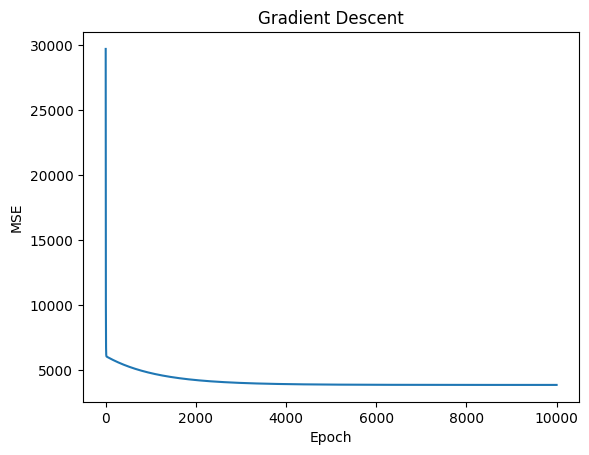

In [73]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent")
plt.show()

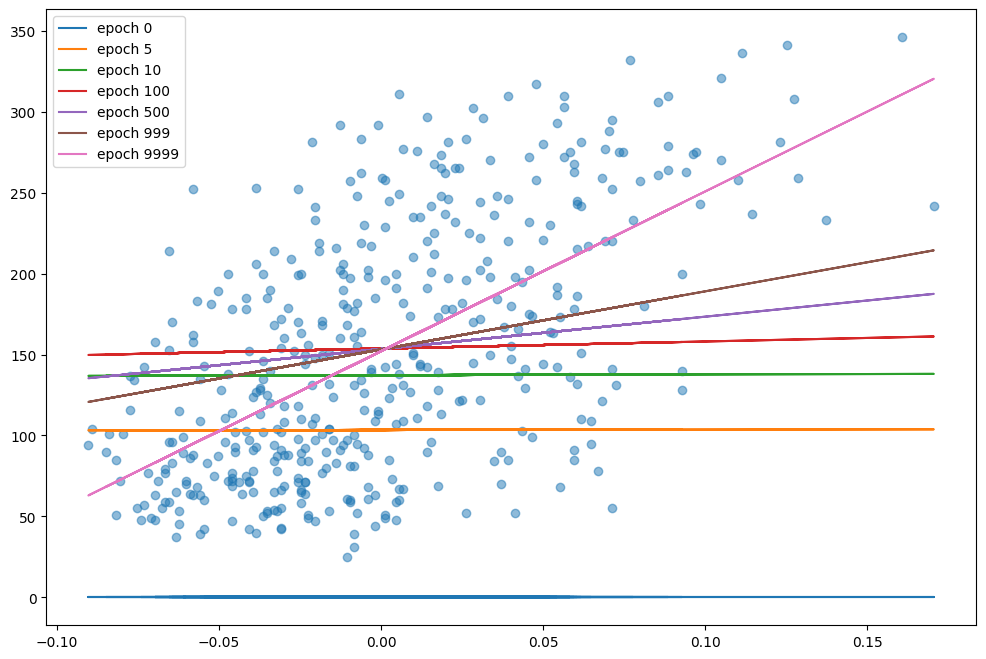

In [78]:
plt.figure(figsize=(12, 8))
plt.scatter(X['bmi'], y, alpha=0.5)

for i in [0, 5, 10, 100, 500, 999, 9999]:
    y_line = w_history[i] * X_test['bmi'] + b_history[i]
    plt.plot(X_test['bmi'], y_line, label=f"epoch {i}")

plt.legend()
plt.show()